# Fair Price Predictor — Capstone Project

## Problem Statement
People traveling by ride-hailing services often don't know what a fair price for their trip should be, making them vulnerable to overcharging. This project builds a regression model that predicts a fair fare based on trip distance, time, and passenger details — giving riders a reference price before they book.

## Step 1: Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

%matplotlib inline

## Step 2: Load and Inspect the Data

Make sure `uber.csv` is in the same folder as this notebook before running the next cell.

In [6]:
df = pd.read_csv('uber.csv')
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 23.4 MB


In [8]:
df.shape

(200000, 9)

In [9]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

## Step 3: Clean the Data

In [10]:
df = df.drop(columns=['Unnamed: 0', 'key'], errors='ignore')
df = df.dropna()

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [11]:
# Remove invalid / unrealistic rows
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 200)]
df = df[(df['pickup_latitude'].between(-90, 90)) & (df['pickup_longitude'].between(-180, 180))]
df = df[(df['dropoff_latitude'].between(-90, 90)) & (df['dropoff_longitude'].between(-180, 180))]
df = df[df['passenger_count'].between(1, 6)]

df.shape

(199248, 7)

## Data Cleaning Note
Removed rows with missing values, invalid GPS coordinates (0,0 or out of range), unrealistic fares (≤$0 or ≥$200, likely data errors), and invalid passenger counts. This ensures the model learns from realistic trips only.

## Step 4: Feature Engineering — Trip Distance (Haversine Formula)

The raw dataset only has pickup/dropoff coordinates, not distance directly — so we calculate it ourselves. This is the single most important engineered feature for predicting fare.

In [12]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

df = df[(df['distance_km'] > 0) & (df['distance_km'] < 100)]
df.shape

(193187, 8)

## Step 5: Feature Engineering — Time-Based Features

In [13]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df[['distance_km', 'hour', 'day_of_week', 'is_weekend']].head()

,distance_km,hour,day_of_week,is_weekend
0,1.683323,19,3,0
1,2.457590,20,4,0
2,5.036377,21,0,0
3,1.661683,8,4,0
4,4.475450,17,3,0


## Engineered Features
- **distance_km**: Calculated using the Haversine formula from pickup/dropoff coordinates — the single strongest predictor of fare price.
- **hour**: Hour of day the trip started, capturing rush-hour pricing patterns.
- **is_weekend**: Whether the trip occurred on a weekend, which may affect demand and pricing.

## Step 6: Exploratory Data Analysis

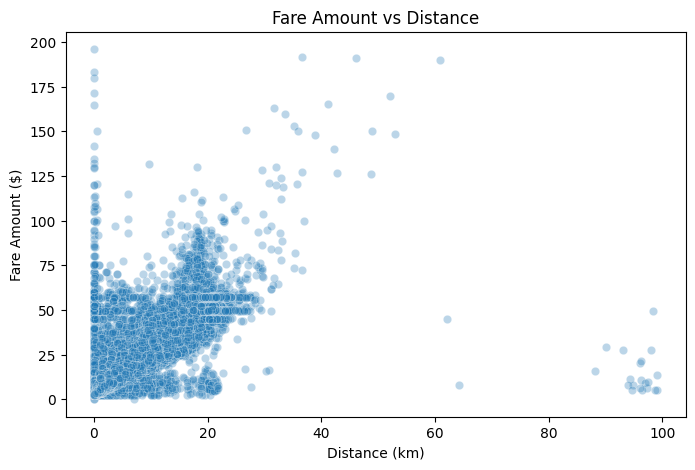

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='distance_km', y='fare_amount', data=df, alpha=0.3)
plt.title('Fare Amount vs Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.show()

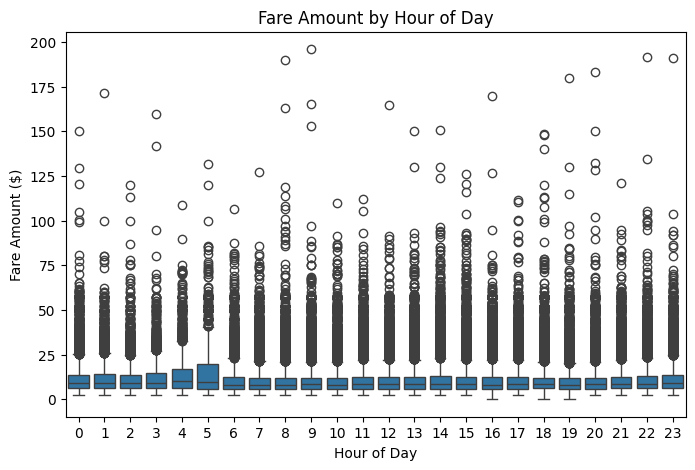

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='hour', y='fare_amount', data=df)
plt.title('Fare Amount by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fare Amount ($)')
plt.show()

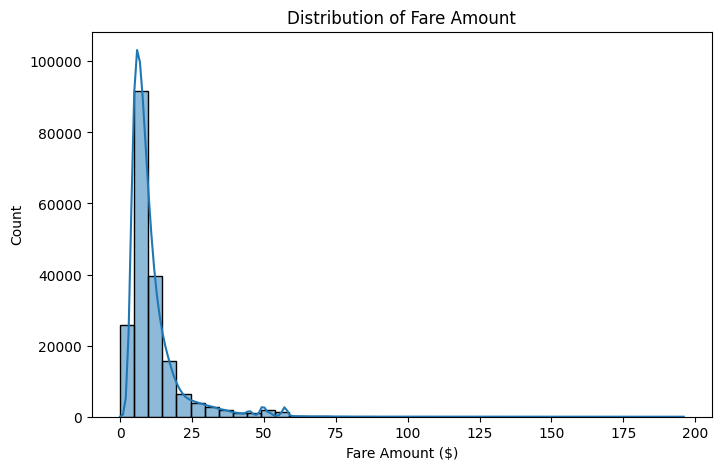

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=40, kde=True)
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.show()

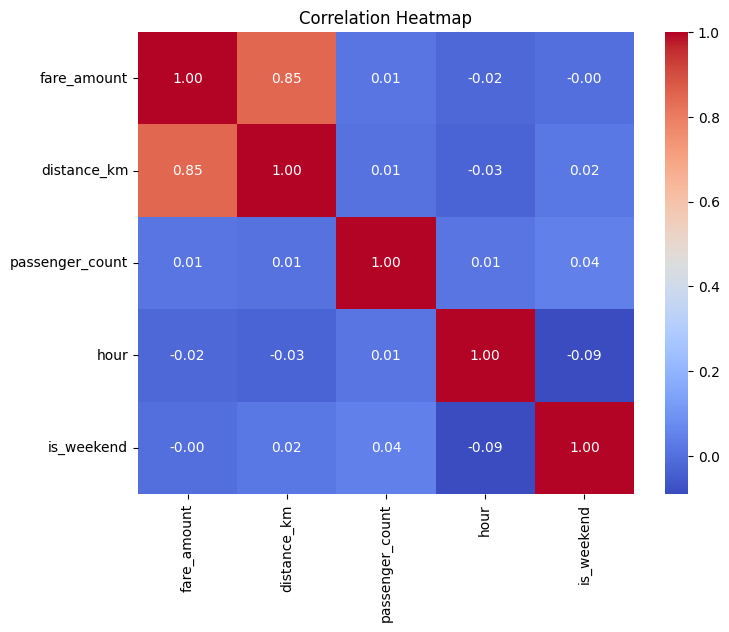

In [17]:
plt.figure(figsize=(8,6))
corr_cols = ['fare_amount', 'distance_km', 'passenger_count', 'hour', 'is_weekend']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## EDA Observations
Fare amount increases clearly with distance, confirming it as the strongest predictor. Time of day shows some variation in fares, likely reflecting traffic and demand patterns. The correlation heatmap confirms `distance_km` has by far the strongest relationship with `fare_amount` among the numeric features.

## Step 7: Select Features and Split Data

In [18]:
features = ['distance_km', 'passenger_count', 'hour', 'is_weekend']
X = df[features]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (154549, 4)
Test set: (38638, 4)


## Step 8: Train Multiple Models

In [25]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [26]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [27]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

## Step 9: Evaluate and Compare Models

In [22]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'R2': r2}

results = pd.DataFrame([
    evaluate(y_test, y_pred_lr, 'Linear Regression'),
    evaluate(y_test, y_pred_rf, 'Random Forest'),
    evaluate(y_test, y_pred_xgb, 'XGBoost')
])
results

,Model,RMSE,R2
0,Linear Regression,5.010613,0.727128
1,Random Forest,4.403514,0.789246
2,XGBoost,4.595344,0.770484


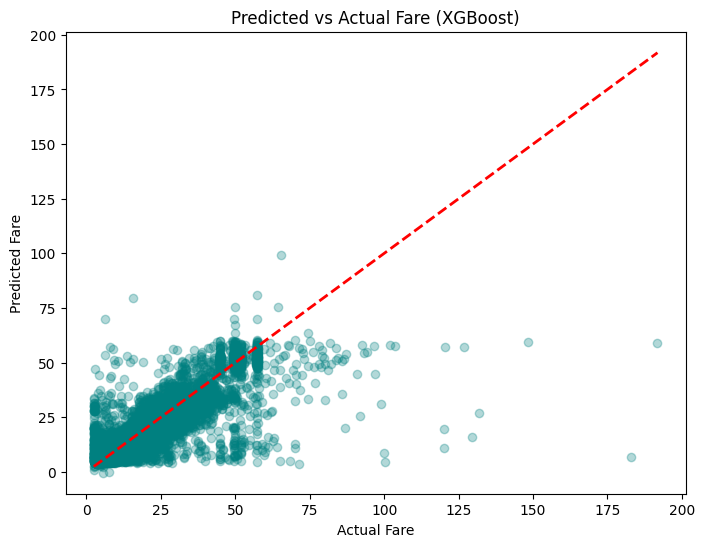

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Predicted vs Actual Fare (XGBoost)')
plt.show()

## Step 10: Pick the Best Model and Save It

Check the `results` table above — whichever model has the **lowest RMSE** and **highest R²** is the best. Update the variable below if a different model wins on your run (commonly XGBoost or Random Forest outperform plain Linear Regression on this kind of data).

In [28]:
best_model = rf_model

joblib.dump(best_model, 'fare_predictor.pkl')
print("Model saved as fare_predictor.pkl")

Model saved as fare_predictor.pkl


## Case Study: Why This Matters
Ride-hailing pricing is often opaque to riders, especially in markets where drivers can negotiate fares directly or surge pricing isn't clearly communicated. This tool addresses that gap by giving riders an independent, data-driven fare estimate before they book — based on distance, time of day, and trip conditions. For a ride-hailing platform or a third-party consumer app, this kind of transparency builds trust and can reduce disputes between riders and drivers. The same underlying approach (distance + time-based pricing) generalizes well beyond Uber's dataset to any point-to-point transport pricing problem, including intercity travel.